In [1]:

from importlib import reload
import os
import sys
# Set up paths for utility imports
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')

os.chdir(current_dir)
# Ensure the utilities directory is in the import path
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
    
import plotting   
 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import expon
from matplotlib.gridspec import GridSpec


np.random.seed(10)


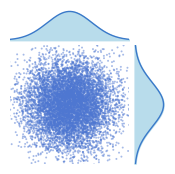

In [ ]:
# -------------------------
# Scatter data
# -------------------------
N = 8000

x = np.random.normal(0, 1.5, N)
y = np.random.normal(0, 1.5, N)


# -------------------------
# Exact Gaussian functions
# -------------------------
xx = np.linspace(-4, 4, 400)

pdf_x = norm.pdf(xx, 0, 1.5)
pdf_y = norm.pdf(xx, 0, 1.5)


# -------------------------
# Figure layout
# -------------------------
fig = plt.figure(figsize=(2,2))

gs = GridSpec(
    2, 2,
    width_ratios=[3,0.8],   # reduce scatter width
    height_ratios=[0.8,3],  # reduce scatter height
    hspace=0.05,
    wspace=0.05
)


ax = fig.add_subplot(gs[1,0])
ax_top = fig.add_subplot(gs[0,0])
ax_right = fig.add_subplot(gs[1,1])


# -------------------------
# Scatter plot
# -------------------------
ax.scatter(
    x,
    y,
    s=2,
    edgecolor="none",
    alpha=0.5,
    color="#4E77D1",
    rasterized=True
)

ax.set_xlim(-4,4)
ax.set_ylim(-4,4)

ax.set_aspect('equal', adjustable='box')

# reduce square frame thickness
for spine in ax.spines.values():
    spine.set_linewidth(0.0)

ax.set_xticks([])
ax.set_yticks([])


# -------------------------
# Top Gaussian PDF
# -------------------------
ax_top.fill_between(
    xx,
    pdf_x,
    color="#B8DCEB"
)

ax_top.plot(
    xx,
    pdf_x,
    color="#3A79C9",
    linewidth=1
)

ax_top.set_xlim(-4,4)
ax_top.axis("off")


# -------------------------
# Right Gaussian PDF
# -------------------------
ax_right.fill_betweenx(
    xx,
    pdf_y,
    color="#B8DCEB"
)

ax_right.plot(
    pdf_y,
    xx,
    color="#3A79C9",
    linewidth=1
)

ax_right.set_ylim(-4,4)
ax_right.axis("off")

plt.savefig("figures/gaussian_sampling_plots.svg", bbox_inches="tight", dpi=300)


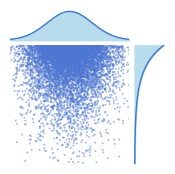

In [ ]:
 


np.random.seed(10)

# -------------------------
# Scatter data
# -------------------------
N = 8000

# Gaussian x
x = np.random.normal(0, 1.5, N)

# Inverted exponential y (dense at top)
y = -np.random.exponential(1.5, N)

# move upward so it occupies [-4,4]
y = y + 4


# -------------------------
# Exact functions
# -------------------------
xx = np.linspace(-4, 4, 400)

# Gaussian top
pdf_x = norm.pdf(xx, 0, 1.5)


# Inverted exponential right
yy = np.linspace(-4, 4, 400)

pdf_y = expon.pdf(-yy + 4, scale=1.5)


# remove negative side
pdf_y[yy > 4] = 0



# -------------------------
# Figure layout
# -------------------------
fig = plt.figure(figsize=(2,2))

gs = GridSpec(
    2, 2,
    width_ratios=[3,0.8],
    height_ratios=[0.8,3],
    hspace=0.05,
    wspace=0.05
)


ax = fig.add_subplot(gs[1,0])
ax_top = fig.add_subplot(gs[0,0])
ax_right = fig.add_subplot(gs[1,1])



# -------------------------
# Scatter
# -------------------------
ax.scatter(
    x,
    y,
    s=2,
    edgecolor="none",
    alpha=0.5,
    color="#4E77D1",
    rasterized=True
)

ax.set_xlim(-4,4)
ax.set_ylim(-4,4)

ax.set_aspect("equal")

for spine in ax.spines.values():
    spine.set_linewidth(0.0)

ax.set_xticks([])
ax.set_yticks([])



# -------------------------
# Top Gaussian
# -------------------------
ax_top.fill_between(
    xx,
    pdf_x,
    color="#B8DCEB"
)

ax_top.plot(
    xx,
    pdf_x,
    color="#3A79C9",
    linewidth=1
)

ax_top.set_xlim(-4,4)
ax_top.axis("off")



# -------------------------
# Right inverted exponential
# -------------------------
ax_right.fill_betweenx(
    yy,
    pdf_y,
    color="#B8DCEB"
)

ax_right.plot(
    pdf_y,
    yy,
    color="#3A79C9",
    linewidth=1
)

ax_right.set_ylim(-4,4)
ax_right.axis("off")



plt.savefig(
    "figures/gaussian_exponential_sampling.svg",
    bbox_inches="tight",
    dpi=300
)
plt.savefig("figures/exponential_sampling_plots.svg", bbox_inches="tight", dpi=300)

